# Machine Learning models applied.

## KNN Neighbors

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns
import warnings

from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder, PowerTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn import neighbors
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, r2_score, explained_variance_score

import scipy.stats as stats
from scipy.stats import kurtosis, boxcox

import mglearn
import matplotlib

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('C:/Users/elias/OneDrive/Desktop/MachineLearning/MLProject/Copia de DataBaseSGC.csv', delimiter=';', low_memory=False)
df

,Record Sequence Number,EQID,Epicenter Latitude (deg; positive N),Epicenter Longitude (deg; positive E),Hypocenter Depth (km),Magnitude,Magnitude type,Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust),Nodal Plane 1 Strike (deg),Nodal Plane 1 Dip (deg),...,Station Elevation (m),Tmax,Valor_T1.5,Repi_OpenQuake,Rjb_OpenQuake,Rrup_OpenQuake,Rx_OpenQuake,Rhypo_OpenQuake,Ry0_OpenQuake,T_0.01_RotD50
0,73,CO_20080524192044,4.374,-73.708,14.7,5.8671,Mw,Crustal,196,82,...,581.0,14,0.07,91.480436,85.352392,86.623229,5.748244,93.551751,85.165829,4.755494
1,74,CO_20100729193445,3.907,-75.097,33.1,5.0567,Mw,Crustal,37,54,...,581.0,15,0.05,96.319115,93.725261,99.461616,8.545095,102.497369,93.435791,10.887828
2,76,CO_19940913100134,7.105,-76.665,14.0,6.0202,Mw,Crustal,4,64,...,1472.0,2,0.09,180.238872,173.579980,174.684394,95.953705,181.353681,146.630792,4.847060
3,79,CO_19961104172500,7.364,-77.380,14.0,6.2562,Mw,Crustal,188,43,...,1472.0,2,0.10,253.961289,244.155697,244.405678,-188.792092,254.752031,154.796223,1.814338
4,84,CO_19990125181918,4.445,-75.659,17.0,6.1355,Mw,Crustal,8,65,...,1472.0,3,0.07,139.662026,134.252237,135.354859,-121.819668,141.709990,56.434882,9.462926
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8806,8774,CO_20190331072713,-1.910,-80.810,5.0,5.6000,Mw,Interface,337,24,...,696.0,27,0.02,1236.021754,1230.674634,1230.049890,1178.334392,1236.043904,374.756057,0.004725
8807,8776,CO_20190331140913,-2.030,-80.890,10.0,5.0181,Mw,Interface,354,21,...,696.0,27,0.02,1253.442350,1249.197259,1248.234684,1023.671482,1253.495004,717.168683,0.003128
8808,8777,CO_20190408032300,-2.120,-80.360,47.0,5.0304,Mw,Interface,334,31,...,696.0,27,0.02,1216.435655,1213.141652,1209.579637,1162.208344,1217.416127,358.488368,0.003101
8809,8778,CO_20190409113955,3.750,-78.740,10.0,5.0266,Mw,Interface,26,32,...,696.0,20,0.02,729.062638,725.469563,725.018483,-469.472251,729.171353,552.584146,0.020313


In [3]:
categorical_columns = df.select_dtypes(include=['object']).columns
categorical_columns

Index(['EQID', 'Magnitude type',
       'Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)',
       'Style-of-Faulting (S; R; N; U)', 'Station ID', 'Station Code'],
      dtype='object')

In [4]:
df.drop(["Record Sequence Number"], axis=1, inplace=True)
df.drop(["Station ID"], axis=1, inplace=True)
df.drop(["Station Code"], axis=1, inplace=True)
df.drop(["Magnitude type"], axis=1, inplace=True)
df.drop(["EQID"], axis=1, inplace=True)
df.drop(["Valor_T1.5"], axis=1, inplace=True)
df.drop(["Tmax"], axis=1, inplace=True)
df.drop(["Epicenter Latitude (deg; positive N)"], axis=1, inplace=True)
df.drop(["Epicenter Longitude (deg; positive E)"], axis=1, inplace=True)
df.drop(["Station Latitude (deg positive N)"], axis=1, inplace=True)
df.drop(["Station Longitude (deg positive E)"], axis=1, inplace=True)

In [5]:
df = df[df['T_0.01_RotD50'] > 0]

In [6]:
df_copy = df.copy()

In [7]:
df_copy["T_0.01_RotD50"]= np.log(df_copy["T_0.01_RotD50"])


In [8]:
df_copy.describe().T

,count,mean,std,min,25%,50%,75%,max
Hypocenter Depth (km),8809.0,60.004416,62.347718,1.000000,10.000000,20.000000,132.000000,209.900000
Magnitude,8809.0,4.988410,0.676019,3.800000,4.500000,4.900000,5.260000,7.782200
Nodal Plane 1 Strike (deg),8809.0,177.646838,106.261691,2.000000,88.000000,168.000000,265.000000,360.000000
Nodal Plane 1 Dip (deg),8809.0,58.327165,23.395052,1.000000,41.000000,65.000000,80.000000,90.000000
Nodal Plane 1 Rake Angle (deg),8809.0,13.527075,109.978298,-180.000000,-69.000000,20.000000,107.000000,180.000000
Nodal Plane 2 Strike (deg),8809.0,169.450335,108.280821,0.000000,71.000000,172.000000,258.000000,360.000000
Nodal Plane 2 Dip (deg),8809.0,68.298558,16.068522,14.000000,58.000000,69.000000,82.000000,90.000000
Nodal Plane 2 Rake Angle (deg),8809.0,18.633897,102.792576,-180.000000,-50.000000,18.000000,100.000000,177.000000
Fault Plane (1; 2; X),8809.0,1.440005,0.496416,1.000000,1.000000,1.000000,2.000000,2.000000
Station Elevation (m),8809.0,1192.927767,1107.990874,4.000000,234.000000,780.000000,1948.000000,4136.000000


In [9]:
df_numerico = df_copy.select_dtypes(include=[float, int])


In [10]:
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Estandarizar datos
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
df_numerico.drop(["Fault Plane (1; 2; X)"], axis=1, inplace=True) #Se va a codificar dsp.
# Escalar las variables predictoras
df_scaled = pd.DataFrame(scaler_X.fit_transform(df_numerico.drop("T_0.01_RotD50", axis=1)), 
                         columns=df_numerico.drop("T_0.01_RotD50", axis=1).columns)
# Escalar la variable de respuesta
Aceleracion_escalada = scaler_y.fit_transform(df_numerico[["T_0.01_RotD50"]])  # Debe ser 2D
df_scaled["T_0.01_RotD50"] = Aceleracion_escalada.flatten()

In [11]:
df_scaled

,Hypocenter Depth (km),Magnitude,Nodal Plane 1 Strike (deg),Nodal Plane 1 Dip (deg),Nodal Plane 1 Rake Angle (deg),Nodal Plane 2 Strike (deg),Nodal Plane 2 Dip (deg),Nodal Plane 2 Rake Angle (deg),Station Elevation (m),Repi_OpenQuake,Rjb_OpenQuake,Rrup_OpenQuake,Rx_OpenQuake,Rhypo_OpenQuake,Ry0_OpenQuake,T_0.01_RotD50
0,0.065582,0.519085,0.541899,0.910112,0.002778,0.294444,0.986842,0.481793,0.139642,0.049285,0.047258,0.041342,0.492622,0.043130,0.049300,0.727553
1,0.153662,0.315579,0.097765,0.595506,0.883333,0.430556,0.565789,0.630252,0.139642,0.051954,0.051893,0.048506,0.493464,0.048102,0.054087,0.770831
2,0.062231,0.557531,0.005587,0.707865,0.525000,0.750000,0.894737,0.932773,0.355276,0.098248,0.096107,0.090482,0.519776,0.091937,0.084880,0.728550
3,0.062231,0.616795,0.519553,0.471910,0.616667,0.177778,0.644737,0.851541,0.355276,0.138917,0.135183,0.129388,0.434061,0.132737,0.089607,0.677210
4,0.076592,0.586485,0.016760,0.719101,0.441667,0.297222,0.750000,0.075630,0.355276,0.075864,0.074332,0.068535,0.454221,0.069900,0.032669,0.763503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8804,0.019148,0.452011,0.935754,0.258427,0.655556,0.536111,0.736842,0.795518,0.167473,0.680668,0.681395,0.679396,0.845595,0.678214,0.216936,0.366315
8805,0.043083,0.305886,0.983240,0.224719,0.744444,0.488889,0.723684,0.759104,0.167473,0.690278,0.691650,0.689543,0.799038,0.687915,0.415149,0.344772
8806,0.220201,0.308975,0.927374,0.337079,0.708333,0.477778,0.605263,0.781513,0.167473,0.669863,0.671687,0.667973,0.840741,0.667859,0.207519,0.344306
8807,0.043083,0.308021,0.067039,0.348315,0.227778,0.597222,0.578947,0.266106,0.167473,0.401005,0.401675,0.397579,0.349570,0.396456,0.319876,0.442509


In [12]:
df_scaled.drop(["Nodal Plane 1 Rake Angle (deg)"], axis=1, inplace=True)
df_scaled.drop(["Nodal Plane 2 Rake Angle (deg)"], axis=1, inplace=True)
df_scaled.drop(["Nodal Plane 2 Dip (deg)"], axis=1, inplace=True)
df_scaled.drop(["Nodal Plane 2 Strike (deg)"], axis=1, inplace=True)
df_scaled.drop(["Rx_OpenQuake"], axis=1, inplace=True)
df_scaled.drop(["Ry0_OpenQuake"], axis=1, inplace=True)
df_scaled.drop(["Rhypo_OpenQuake"], axis=1, inplace=True)
df_scaled.drop(["Rrup_OpenQuake"], axis=1, inplace=True)
df_scaled.drop(["Repi_OpenQuake"], axis=1, inplace=True)

In [13]:
# Codificar la variable categórica con OneHotEncoder
X_categorical = df_copy[['Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)']].astype(str)

enc = OneHotEncoder(sparse_output=False)
X_encoded = enc.fit_transform(X_categorical)  # Devuelve un array listo para KNN

Y_categorical = df_copy[["Fault Plane (1; 2; X)"]].astype(str)

enc = OneHotEncoder(sparse_output=False)
Y_encoded = enc.fit_transform(Y_categorical)  

Z_categorical = df_copy[["Style-of-Faulting (S; R; N; U)"]].astype(str)

enc = OneHotEncoder(sparse_output=False)
Z_encoded = enc.fit_transform(Z_categorical)  

X_numerical = df_scaled.drop(columns=["T_0.01_RotD50"]).values

# Paso 3: Combinar características numéricas y codificadas
X_final = np.hstack((X_numerical, X_encoded,Y_encoded,Z_encoded))

y = df_scaled["T_0.01_RotD50"].values  


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.25, random_state=0)

In [15]:
df_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
Hypocenter Depth (km),8809.0,0.282453,0.298457,0.0,0.043083,0.090953,0.627094,1.0
Magnitude,8809.0,0.298430,0.169760,0.0,0.175782,0.276229,0.366632,1.0
Nodal Plane 1 Strike (deg),8809.0,0.490634,0.296820,0.0,0.240223,0.463687,0.734637,1.0
Nodal Plane 1 Dip (deg),8809.0,0.644125,0.262866,0.0,0.449438,0.719101,0.887640,1.0
Station Elevation (m),8809.0,0.287737,0.268149,0.0,0.055663,0.187803,0.470474,1.0
Rjb_OpenQuake,8809.0,0.285114,0.198489,0.0,0.133736,0.239893,0.396430,1.0
T_0.01_RotD50,8809.0,0.558826,0.121876,0.0,0.463656,0.546515,0.646467,1.0


In [16]:
rmsle_val = []
best_rmsle = 1.0

for k in range(20):
    k = k+1
    knn = neighbors.KNeighborsRegressor(n_neighbors = k)
    knn.fit(X_train, y_train) 
    y_pred = knn.predict(X_test)
    rmsle = np.sqrt(mean_squared_log_error(y_test,y_pred))
    if (rmsle < best_rmsle):
        best_rmsle = rmsle
        best_k = k
    rmsle_val.append(rmsle)
    print('RMSLE value for k= ' , k , 'is:', rmsle)

print(f"Best RMSLE: {best_rmsle}, Best k: {best_k}")

RMSLE value for k=  1 is: 0.06030474146511146
RMSLE value for k=  2 is: 0.0517312877031794
RMSLE value for k=  3 is: 0.04948777646699365
RMSLE value for k=  4 is: 0.0485939841896744
RMSLE value for k=  5 is: 0.04863133284402343
RMSLE value for k=  6 is: 0.04820140906873662
RMSLE value for k=  7 is: 0.04801468716557058
RMSLE value for k=  8 is: 0.048253261763792264
RMSLE value for k=  9 is: 0.048243789827616394
RMSLE value for k=  10 is: 0.04852713133289467
RMSLE value for k=  11 is: 0.04863408183550073
RMSLE value for k=  12 is: 0.04883184195745926
RMSLE value for k=  13 is: 0.04892784252695224
RMSLE value for k=  14 is: 0.04914836655789553
RMSLE value for k=  15 is: 0.04923763275995367
RMSLE value for k=  16 is: 0.04933388650369725
RMSLE value for k=  17 is: 0.049461491268096035
RMSLE value for k=  18 is: 0.04965604495346854
RMSLE value for k=  19 is: 0.049830483137070905
RMSLE value for k=  20 is: 0.049998408217304446
Best RMSLE: 0.04801468716557058, Best k: 7


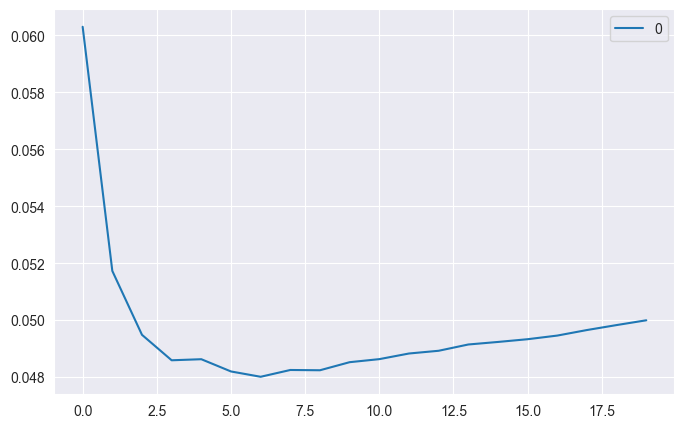

In [17]:
sns.set_style("darkgrid")
curve = pd.DataFrame(rmsle_val)
curve.plot(figsize=(8,5));
#plt.style.use("bmh")

In [18]:
knn = neighbors.KNeighborsRegressor(n_neighbors = 7)

knn.fit(X_train,y_train)
y_pred = knn.predict(X_test)
print("Puntaje test: ",knn.score(X_test, y_test))
print("Puntaje train: ",knn.score(X_train, y_train))

y_predtotal=knn.predict(X_final)
puntajetotal=knn.score(X_final,y)
print("Puntaje conjunto total: ", puntajetotal)

Puntaje test:  0.6274141053078515
Puntaje train:  0.7101510784948222
Puntaje conjunto total:  0.6896395010044846


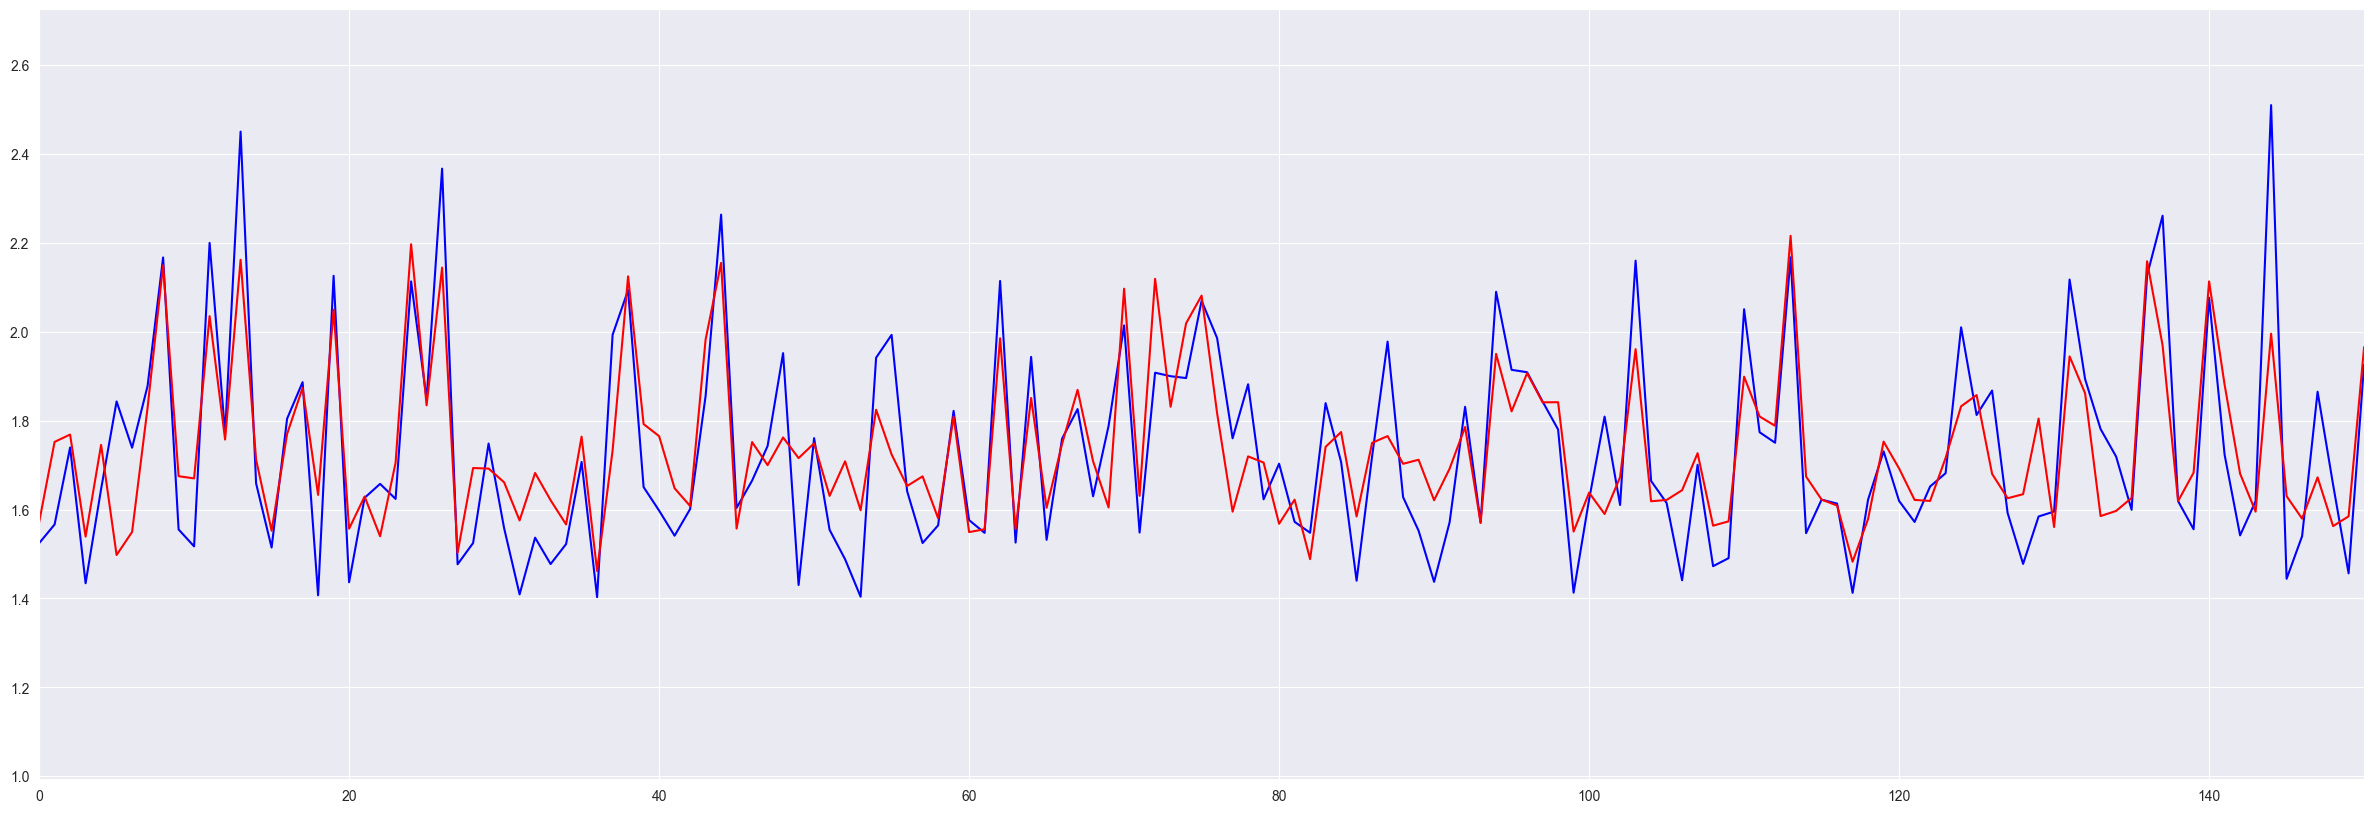

In [19]:

# Ordenamos los valores reales y sus predicciones para que la línea tenga sentido
plt.figure(figsize=(30, 10))
sorted_indices = np.argsort(y_test)  # Obtiene los índices que ordenan y_test

plt.plot(np.exp(y_test), linestyle="-", color = "Blue")
plt.plot(np.exp(y_pred), linestyle="-", color = "Red")
plt.xlim([0,150])
plt.show()

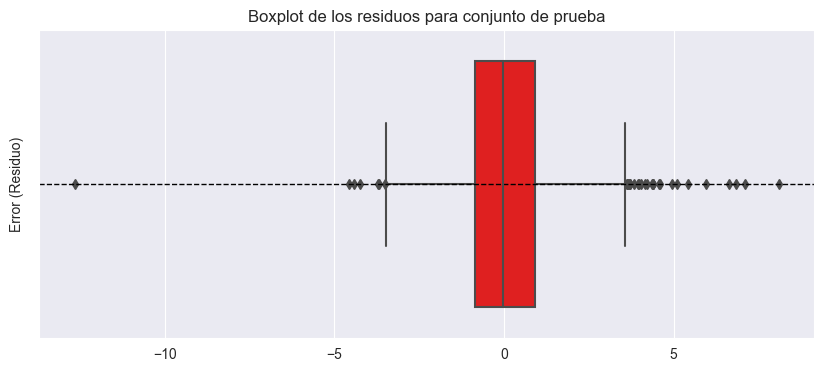

In [20]:
y_test_unscaled = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_unscaled = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()
y_test_original = np.exp(y_test_unscaled)
y_pred_original = np.exp(y_pred_unscaled)

residuos = y_test_unscaled  - y_pred_unscaled  # Diferencia entre valores logaritmicos reales y predichos
residuosreales = y_test_original - y_pred_original

plt.figure(figsize=(10,4))
sns.boxplot(x=residuos, orient="h", color="red")
plt.axhline(y=0, color="black", linestyle="--", linewidth=1)  # Línea en y=0
plt.ylabel("Error (Residuo)")
plt.title("Boxplot de los residuos para conjunto de prueba")

plt.show()



In [21]:
ylogreal = scaler_y.inverse_transform(y.reshape(-1, 1)).flatten()
ylogpred= scaler_y.inverse_transform(y_predtotal.reshape(-1, 1)).flatten()
residuos_log = ylogpred-ylogreal
yREAL = np.exp(ylogreal)
ypredREAL = np.exp(ylogpred)
residuos_totales = yREAL - ypredREAL

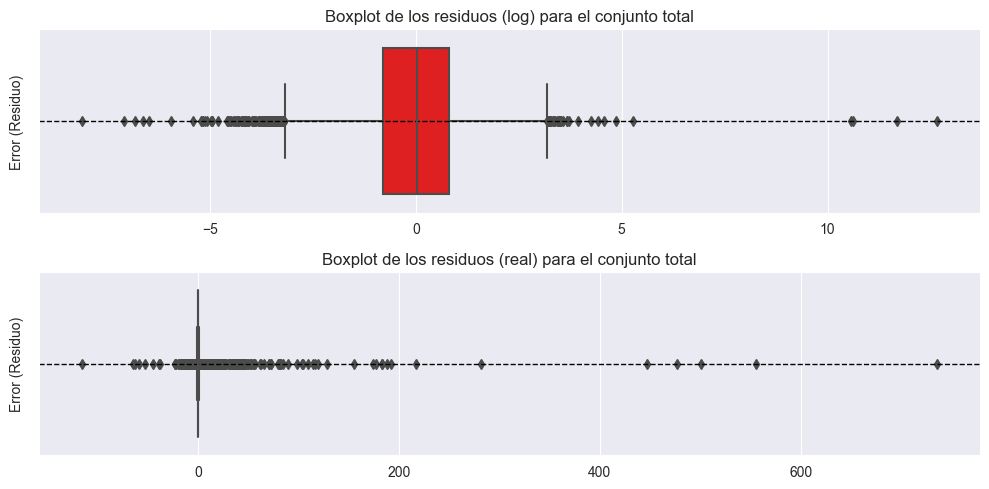

In [22]:

fig, axes = plt.subplots(2, 1, figsize=(10, 5))

sns.boxplot(x=residuos_log, orient="h", color="red", ax=axes[0])
axes[0].axhline(y=0, color="black", linestyle="--", linewidth=1)  
axes[0].set_ylabel("Error (Residuo)")
axes[0].set_title("Boxplot de los residuos (log) para el conjunto total")

sns.boxplot(x=residuos_totales, orient="h", color="red", ax=axes[1])
axes[1].axhline(y=0, color="black", linestyle="--", linewidth=1) 
axes[1].set_ylabel("Error (Residuo)")
axes[1].set_title("Boxplot de los residuos (real) para el conjunto total")

plt.tight_layout()

plt.show()
re = pd.DataFrame({
    'Residuo Log': residuos_log,
    'Residuo Totales': residuos_totales
})

In [23]:
re.describe()

,Residuo Log,Residuo Totales
count,8809.000000,8809.000000
mean,-0.024633,1.451620
std,1.299332,16.005855
min,-8.105758,-115.332105
25%,-0.796791,-0.055523
50%,0.036945,-0.002266
75%,0.794425,0.260391
max,12.662456,735.631049


## Regresión Ridge

In [24]:
# Estandarizar datos
scaler_XRidge = MinMaxScaler()
scaler_yRidge = MinMaxScaler()
#df_numerico.drop(["Fault Plane (1; 2; X)"], axis=1, inplace=True) #Se va a codificar dsp.
# Escalar las variables predictoras
df_scaledRidge = pd.DataFrame(scaler_XRidge.fit_transform(df_numerico.drop("T_0.01_RotD50", axis=1)), 
                         columns=df_numerico.drop("T_0.01_RotD50", axis=1).columns)
# Escalar la variable de respuesta
Aceleracion_escalada = scaler_yRidge.fit_transform(df_numerico[["T_0.01_RotD50"]])  # Debe ser 2D
df_scaledRidge["T_0.01_RotD50"] = Aceleracion_escalada.flatten()

In [25]:
df_scaledRidge

,Hypocenter Depth (km),Magnitude,Nodal Plane 1 Strike (deg),Nodal Plane 1 Dip (deg),Nodal Plane 1 Rake Angle (deg),Nodal Plane 2 Strike (deg),Nodal Plane 2 Dip (deg),Nodal Plane 2 Rake Angle (deg),Station Elevation (m),Repi_OpenQuake,Rjb_OpenQuake,Rrup_OpenQuake,Rx_OpenQuake,Rhypo_OpenQuake,Ry0_OpenQuake,T_0.01_RotD50
0,0.065582,0.519085,0.541899,0.910112,0.002778,0.294444,0.986842,0.481793,0.139642,0.049285,0.047258,0.041342,0.492622,0.043130,0.049300,0.727553
1,0.153662,0.315579,0.097765,0.595506,0.883333,0.430556,0.565789,0.630252,0.139642,0.051954,0.051893,0.048506,0.493464,0.048102,0.054087,0.770831
2,0.062231,0.557531,0.005587,0.707865,0.525000,0.750000,0.894737,0.932773,0.355276,0.098248,0.096107,0.090482,0.519776,0.091937,0.084880,0.728550
3,0.062231,0.616795,0.519553,0.471910,0.616667,0.177778,0.644737,0.851541,0.355276,0.138917,0.135183,0.129388,0.434061,0.132737,0.089607,0.677210
4,0.076592,0.586485,0.016760,0.719101,0.441667,0.297222,0.750000,0.075630,0.355276,0.075864,0.074332,0.068535,0.454221,0.069900,0.032669,0.763503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8804,0.019148,0.452011,0.935754,0.258427,0.655556,0.536111,0.736842,0.795518,0.167473,0.680668,0.681395,0.679396,0.845595,0.678214,0.216936,0.366315
8805,0.043083,0.305886,0.983240,0.224719,0.744444,0.488889,0.723684,0.759104,0.167473,0.690278,0.691650,0.689543,0.799038,0.687915,0.415149,0.344772
8806,0.220201,0.308975,0.927374,0.337079,0.708333,0.477778,0.605263,0.781513,0.167473,0.669863,0.671687,0.667973,0.840741,0.667859,0.207519,0.344306
8807,0.043083,0.308021,0.067039,0.348315,0.227778,0.597222,0.578947,0.266106,0.167473,0.401005,0.401675,0.397579,0.349570,0.396456,0.319876,0.442509


In [26]:
X_numericalRidge = df_scaledRidge.drop(columns=["T_0.01_RotD50"]).values
yRidge = df_scaledRidge["T_0.01_RotD50"].values

In [27]:
# Paso 3: Combinar características numéricas y codificadas
X_finalRidge = np.hstack((X_numericalRidge, X_encoded,Y_encoded,Z_encoded))

In [28]:
X_trainRidge, X_testRidge, y_trainRidge, y_testRidge = train_test_split(X_finalRidge, yRidge, test_size=0.25, random_state=0)

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [30]:
lr = LinearRegression().fit(X_trainRidge, y_trainRidge)

In [31]:
print("lr.coef_: {}".format(lr.coef_))
print("lr.intercept_: {}".format(lr.intercept_))

lr.coef_: [-7.91534671e-02  2.17252487e-01 -2.60662972e-03 -6.09579893e-03
 -8.53359907e-03 -1.01898556e-02  3.21373693e-03 -6.32277508e-03
 -4.84801007e-03  5.70564052e+00 -7.77166017e+00  2.28056553e+00
 -2.34304053e-02 -5.46196273e-01  6.78190523e-03 -4.06989432e-04
  3.67296264e-02  1.98046997e-03 -3.83031069e-02  1.25779880e-04
 -1.25779879e-04 -8.48515312e-03  3.00221669e-03  5.48293643e-03]
lr.intercept_: 0.6292991351146107


In [32]:
print("Training set score: {:.2f}".format(lr.score(X_trainRidge, y_trainRidge)))
print("Test set score: {:.2f}".format(lr.score(X_testRidge, y_testRidge)))

Training set score: 0.53
Test set score: 0.52


In [33]:
from sklearn.linear_model import Ridge

In [34]:
ridge = Ridge(alpha=10).fit(X_trainRidge, y_trainRidge)
print("Training set score: {:.2f}".format(ridge.score(X_trainRidge, y_trainRidge)))
print("Test set score: {:.2f}".format(ridge.score(X_testRidge, y_testRidge)))

Training set score: 0.51
Test set score: 0.49


## Lasso

In [35]:
from sklearn.linear_model import Lasso
lasso = Lasso().fit(X_train, y_train)
print("Training set score: {:.2f}".format(lasso.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lasso.score(X_test, y_test)))
print("Number of features used: {}".format(np.sum(lasso.coef_ != 0)))

Training set score: 0.00
Test set score: -0.00
Number of features used: 0


In [36]:
lasso001 = Lasso(alpha=0.001, max_iter=10000000).fit(X_train, y_train)
print("Training set score: {:.2f}".format(lasso001.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lasso001.score(X_test, y_test)))
print("Number of features used: {}".format(np.sum(lasso001.coef_ != 0)))

Training set score: 0.50
Test set score: 0.49
Number of features used: 6


## XGBoost